In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F

In [2]:
IMAGE_SIZE = 256

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

In [3]:
dataset = datasets.ImageFolder(root='D:\Projects\Plant Disease\datasets', transform=transform)

In [4]:
classes = dataset.classes
print(dataset.classes)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [5]:
len(dataset)

20638

In [6]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

In [7]:
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

In [8]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 16510
Validation dataset size: 2063
Test dataset size: 2065


In [9]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle=False)

In [10]:
print(f"Train dataset size: {len(train_loader)}")
print(f"Validation dataset size: {len(val_loader)}")
print(f"Test dataset size: {len(test_loader)}")

Train dataset size: 516
Validation dataset size: 65
Test dataset size: 65


In [11]:
img, lab = train_dataset[0]
img.shape

torch.Size([3, 256, 256])

In [12]:
batch_img, batch_lab = next(iter(train_loader))
batch_img.shape, batch_lab.shape

(torch.Size([32, 3, 256, 256]), torch.Size([32]))

In [13]:
batch_img[0]

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

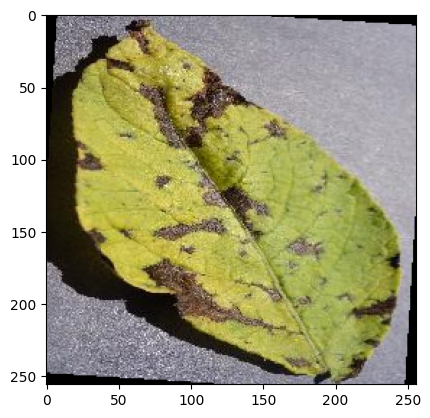

In [14]:
import matplotlib.pyplot as plt

plt.imshow(batch_img[25].permute(1, 2, 0))

## Model Building

In [15]:
class model(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(512 * 8 * 8, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, x):
        
        x = F.interpolate(x, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False)

        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.relu(self.conv3(x))
        x = self.pool(x)
        x = torch.relu(self.conv4(x))
        x = self.pool(x)
        x = torch.relu(self.conv5(x))
        x = self.pool(x)

        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [16]:
from torchinfo import summary

In [17]:
summary(model(num_classes=len(classes)), input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
model                                    [1, 15]                   --
├─Conv2d: 1-1                            [1, 32, 256, 256]         896
├─MaxPool2d: 1-2                         [1, 32, 128, 128]         --
├─Conv2d: 1-3                            [1, 64, 128, 128]         18,496
├─MaxPool2d: 1-4                         [1, 64, 64, 64]           --
├─Conv2d: 1-5                            [1, 128, 64, 64]          73,856
├─MaxPool2d: 1-6                         [1, 128, 32, 32]          --
├─Conv2d: 1-7                            [1, 256, 32, 32]          295,168
├─MaxPool2d: 1-8                         [1, 256, 16, 16]          --
├─Conv2d: 1-9                            [1, 512, 16, 16]          1,180,160
├─MaxPool2d: 1-10                        [1, 512, 8, 8]            --
├─Flatten: 1-11                          [1, 32768]                --
├─Linear: 1-12                           [1, 1024]              

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model(num_classes=len(classes)).to(device)

print("Model device:", next(model.parameters()).device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
) 

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Model device: cuda:0


In [19]:
for epoch in range(50):
    model.train()
    running_loss = 0.0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch + 1}/50], Loss: {epoch_loss:.4f}")
    
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    print(f"Validation Loss: {val_epoch_loss:.4f}, Accuracy: {val_accuracy:.2f}%")

Epoch [1/50], Loss: 1.7299
Validation Loss: 0.9694, Accuracy: 67.18%
Epoch [2/50], Loss: 0.8172
Validation Loss: 0.6867, Accuracy: 76.05%
Epoch [3/50], Loss: 0.5481
Validation Loss: 0.4546, Accuracy: 85.12%
Epoch [4/50], Loss: 0.3950
Validation Loss: 0.4075, Accuracy: 87.83%
Epoch [5/50], Loss: 0.2975
Validation Loss: 0.2982, Accuracy: 91.03%
Epoch [6/50], Loss: 0.2289
Validation Loss: 0.2863, Accuracy: 92.29%
Epoch [7/50], Loss: 0.1828
Validation Loss: 0.2827, Accuracy: 92.05%
Epoch [8/50], Loss: 0.1542
Validation Loss: 0.2507, Accuracy: 93.26%
Epoch [9/50], Loss: 0.1545
Validation Loss: 0.3036, Accuracy: 91.71%
Epoch [10/50], Loss: 0.1335
Validation Loss: 0.2936, Accuracy: 92.49%
Epoch [11/50], Loss: 0.1058
Validation Loss: 0.2524, Accuracy: 93.41%
Epoch [12/50], Loss: 0.1061
Validation Loss: 0.2780, Accuracy: 92.78%
Epoch [13/50], Loss: 0.0884
Validation Loss: 0.3119, Accuracy: 93.26%
Epoch [14/50], Loss: 0.0989
Validation Loss: 0.2627, Accuracy: 93.75%
Epoch [15/50], Loss: 0.0771
V

In [24]:
model.eval()
test_loss = 0
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Loss: {test_loss / len(test_loader):.4f}")
print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Loss: 0.2767
Test Accuracy: 94.33%


In [23]:
len(train_loader)

516

Predicted: 5, Actual: 5
Predicted: 9, Actual: 9
Predicted: 9, Actual: 9
Predicted: 3, Actual: 3
Predicted: 12, Actual: 12
Predicted: 8, Actual: 8
Predicted: 14, Actual: 14
Predicted: 7, Actual: 7
Predicted: 0, Actual: 0
Predicted: 8, Actual: 8
Predicted: 3, Actual: 3
Predicted: 2, Actual: 6
Predicted: 5, Actual: 5
Predicted: 9, Actual: 9
Predicted: 12, Actual: 12
Predicted: 1, Actual: 1
Predicted: 10, Actual: 10
Predicted: 5, Actual: 5
Predicted: 7, Actual: 7
Predicted: 13, Actual: 13
Predicted: 5, Actual: 5
Predicted: 7, Actual: 7
Predicted: 10, Actual: 10
Predicted: 14, Actual: 14
Predicted: 1, Actual: 1
Predicted: 7, Actual: 7
Predicted: 1, Actual: 1
Predicted: 4, Actual: 4
Predicted: 12, Actual: 12
Predicted: 14, Actual: 14
Predicted: 12, Actual: 12
Predicted: 6, Actual: 6
Predicted: 12, Actual: 12
Predicted: 5, Actual: 5
Predicted: 7, Actual: 7
Predicted: 6, Actual: 6
Predicted: 9, Actual: 9
Predicted: 7, Actual: 7
Predicted: 12, Actual: 12
Predicted: 12, Actual: 12
Predicted: 14,

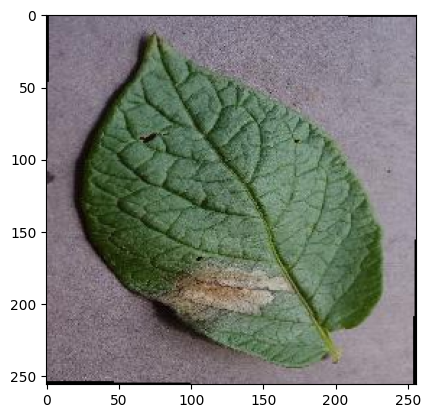

In [22]:
for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

    print(f"Predicted: {predicted[0]}, Actual: {labels[0]}")

    plt.imshow(images[0].cpu().permute(1, 2, 0))

In [25]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": classes,
    "num_classes": len(classes)
}, "plant_disease_model.pth")